In [1]:
import pandas as pd

In [2]:
df_praias = pd.read_json("praias.geojson")

In [3]:
df_praias["features"].head()

0    {'type': 'Feature', 'properties': {'@id': 'rel...
1    {'type': 'Feature', 'properties': {'@id': 'rel...
2    {'type': 'Feature', 'properties': {'@id': 'rel...
3    {'type': 'Feature', 'properties': {'@id': 'rel...
4    {'type': 'Feature', 'properties': {'@id': 'rel...
Name: features, dtype: object

In [4]:
import geopandas as gpd

# 1. Carregar o arquivo GeoJSON
# Substitua 'praias.geojson' pelo caminho real do seu arquivo
gdf = gpd.read_file("praias.geojson")

# 2. Visualizar as primeiras linhas para entender a estrutura
print("Visão geral dos dados:")
print(gdf.head())

# 3. Filtrar e acessar colunas específicas (como o nome e a geometria)
print("\nNomes e Geometrias:")
praias_info = gdf[['name', 'geometry']]
print(praias_info)

# 4. Acessar os dados de uma praia específica (ex: a primeira da lista)
primeira_praia = gdf.iloc[0]
print(f"\nNome da primeira praia: {primeira_praia['name']}")
print(f"Tipo de superfície: {primeira_praia['surface']}")
print(f"Geometria (Polígono): {primeira_praia['geometry']}")

Visão geral dos dados:
                 id               @id GNS:id access alt_name  bin camera  \
0  relation/5514745  relation/5514745    NaN    NaN      NaN  NaN    NaN   
1  relation/5528552  relation/5528552    NaN    NaN      NaN  NaN    NaN   
2  relation/5538960  relation/5538960    NaN    NaN      NaN  NaN    NaN   
3  relation/5538961  relation/5538961    NaN    NaN      NaN  NaN    NaN   
4  relation/5538962  relation/5538962    NaN    NaN      NaN  NaN    NaN   

  camping clothing-optional description  ... topless tourism tripadvisor  \
0     NaN               NaN         NaN  ...     NaN     NaN         NaN   
1     NaN               NaN         NaN  ...     NaN     NaN         NaN   
2     NaN               NaN         NaN  ...     NaN     NaN         NaN   
3     NaN               NaN         NaN  ...     NaN     NaN         NaN   
4     NaN               NaN         NaN  ...     NaN     NaN         NaN   

           type  url website   wikidata wikimedia_commons  \
0 

In [5]:
dic_praias = [
    "Praia de Copacabana", "Praia de Ipanema", "Praia do Leblon", "Praia do Arpoador", "Praia do Leme", "Praia Vermelha", "Praia da Urca",
    "Praia da Barra da Tijuca", "Praia do Recreio dos Bandeirantes", "Praia da Reserva", "Prainha",
     "Praia de Grumari", "Praia da Macumba", "Praia do Abricó", "Praia de São Conrado",
    "Praia da Joatinga", "Praia de Ramos", "Praia da Ilha do Governador", "Praia da Guarda", "Praia da Moreninha", "Praia José Bonifácio", "Praia da Ribeira", "Praia Grande", 
    "Praia do Farol", "Praia da Figueira", 

]

In [6]:
gdf_filtrado = gdf[gdf['name'].isin(dic_praias)]

# gdf_filtrado.to_file('praias_filtradas.geojson', driver='GeoJSON')

print(f"Total de praias original: {len(gdf)}")
print(f"Total de praias após o filtro: {len(gdf_filtrado)}")

Total de praias original: 134
Total de praias após o filtro: 20


In [7]:
gdf_filtrado.to_file('praias_filtradas.geojson', driver='GeoJSON')

In [8]:
df_anuncios = pd.read_csv('AirBnBLimpo.csv')

In [9]:
df_anuncios = df_anuncios[df_anuncios["price_cleaned"] <=2000] 
df_anuncios = df_anuncios[df_anuncios["beds"]>0]

In [10]:
df_anuncios.head()

,Unnamed: 0,id,name,len_description,len_name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,...,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable,price_cleaned,bairro_perigoso
0,0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",533,49,Matthias,"Rio de Janeiro, Brazil",NaN,True,NaN,...,2.0,2.0,$565.00,5.0,350,1,4.72,True,565.00,0
1,1,25026,Beautiful Modern Decorated Studio in Copacabana,524,47,Viviane,"Rio de Janeiro, Brazil",NaN,True,NaN,...,1.0,2.0,$542.50,2.0,325,2,4.76,True,542.50,0
2,2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,314,47,Patricia&Paulo,"Rio de Janeiro, Brazil",NaN,True,NaN,...,1.0,1.0,$369.00,3.0,548,5,4.90,True,369.00,0
4,4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,267,50,Marcio,"Cabo Frio, Brazil",NaN,False,NaN,...,4.0,5.0,"$1,314.67",1.0,68,4,4.65,True,1314.67,0
5,5,49179,Copacabana Ocean View Studio • Posto 5,399,38,David,"Mesa, AZ",NaN,True,NaN,...,1.0,1.0,$339.50,4.0,202,1,4.85,True,339.50,0


In [11]:
lon_alvo = df_anuncios["longitude"].iloc[1]
lat_alvo = df_anuncios["latitude"].iloc[1]

In [12]:
from shapely.geometry import Point

In [13]:
ponto_original = gpd.GeoSeries([Point(lon_alvo, lat_alvo)], crs="EPSG:4326")

gdf_metrico = gdf.to_crs(epsg=31983)
ponto_metrico = ponto_original.to_crs(epsg=31983).geometry.iloc[0]

gdf['distancia_metros'] = gdf_metrico.distance(ponto_metrico)

gdf['distancia_km'] = gdf['distancia_metros'] / 1000

print("Praias mais próximas do ponto alvo:")
resultado = gdf[['name', 'distancia_km']].sort_values(by='distancia_km')
print(resultado)

Praias mais próximas do ponto alvo:
                    name  distancia_km
0    Praia de Copacabana      0.322526
26        Praia do Forte      1.221152
27        Praia do Forte      1.281575
83     Praia do Arpoador      1.324946
55      Praia de Ipanema      1.331547
..                   ...           ...
109                  NaN     47.767082
10                   NaN     50.558469
14    Praia do Recôncavo     51.305194
16     Praia de Sepetiba     52.476786
15     Praia de Sepetiba     52.830149

[134 rows x 2 columns]


In [14]:
cristo_lat = -22.9519
cristo_lon = -43.2105

bondinho_lat = -22.9488
bondinho_long = -43.1554

ufrj_lat = -22.852794
ufrj_lon = -43.233907

In [15]:
gdf_anuncios = gpd.GeoDataFrame(
    df_anuncios, 
    geometry=gpd.points_from_xy(df_anuncios.longitude, df_anuncios.latitude),
    crs="EPSG:4326" # Define que os dados de origem estão em graus (Lat/Lon)
)

# 2. Converter o GeoDataFrame para o sistema UTM local (Rio de Janeiro: EPSG 31983)
# Isso permite que a distância calculada seja em metros
gdf_anuncios = gdf_anuncios.to_crs(epsg=31983)

# 3. Definir os pontos de referência (sempre em Longitude, Latitude)
# E já converter cada um deles para o mesmo sistema UTM (EPSG 31983)
cristo = gpd.GeoSeries([Point(-43.2105, -22.9519)], crs="EPSG:4326").to_crs(epsg=31983).iloc[0]
bondinho = gpd.GeoSeries([Point(-43.1554, -22.9488)], crs="EPSG:4326").to_crs(epsg=31983).iloc[0]
ufrj = gpd.GeoSeries([Point(-43.233907, -22.852794)], crs="EPSG:4326").to_crs(epsg=31983).iloc[0]

# 4. Calcular as distâncias
# O método .distance() calculará a distância euclidiana no plano UTM (em metros)
gdf_anuncios['distancia_cristo_m'] = gdf_anuncios.geometry.distance(cristo)
gdf_anuncios['distancia_bondinho_m'] = gdf_anuncios.geometry.distance(bondinho)
gdf_anuncios['distancia_ufrj_m'] = gdf_anuncios.geometry.distance(ufrj)

# 5. Opcional: Converter para Quilômetros para facilitar a leitura
gdf_anuncios['distancia_cristo_km'] = gdf_anuncios['distancia_cristo_m'] / 1000
gdf_anuncios['distancia_bondinho_km'] = gdf_anuncios['distancia_bondinho_m'] / 1000
gdf_anuncios['distancia_ufrj_km'] = gdf_anuncios['distancia_ufrj_m'] / 1000

# Exibindo o resultado final
print(gdf_anuncios[['latitude', 'longitude', 'distancia_cristo_km', 'distancia_bondinho_km', 'distancia_ufrj_km']].head())

df_anuncios['distancia_cristo_km'] = gdf_anuncios['distancia_cristo_km']
df_anuncios['distancia_bondinho_km'] = gdf_anuncios['distancia_bondinho_km']
df_anuncios['distancia_ufrj_km'] = gdf_anuncios['distancia_ufrj_km']


   latitude  longitude  distancia_cristo_km  distancia_bondinho_km  \
0 -22.96599  -43.17940             3.550735               3.111712   
1 -22.97649  -43.19122             3.365313               4.785237   
2 -22.98107  -43.19136             3.780005               5.135357   
4 -22.96574  -43.17514             3.936992               2.760116   
5 -22.97910  -43.19008             3.668659               4.889717   

   distancia_ufrj_km  
0          13.726561  
1          14.381598  
2          14.861281  
4          13.885405  
5          14.692538  


In [16]:
import geopandas as gpd
from shapely.geometry import Point

# --- 1. CARREGAR E PREPARAR OS DADOS ---

# Carregar o arquivo de praias (já filtrado)
gdf_praias = gpd.read_file('praias_filtradas.geojson')

# Supondo que você já tenha o seu df_anuncios carregado na memória...
# Convertemos o df_anuncios em um GeoDataFrame (definindo as colunas de longitude e latitude)
# Importante: No Shapely, a ordem sempre é (X, Y) -> (Longitude, Latitude)
gdf_anuncios = gpd.GeoDataFrame(
    df_anuncios, 
    geometry=gpd.points_from_xy(df_anuncios['longitude'], df_anuncios['latitude']),
    crs="EPSG:4326" # Define que o sistema original está em graus (WGS84)
)

# --- 2. REPROJETAR PARA SISTEMA MÉTRICO (MUITO IMPORTANTE) ---
# Reprojetamos ambos para o sistema UTM da região do Rio de Janeiro (EPSG:31983) 
# para garantir que o cálculo da distância seja feito em metros, e não em graus.
gdf_praias_m = gdf_praias.to_crs(epsg=31983)
gdf_anuncios_m = gdf_anuncios.to_crs(epsg=31983)

# --- 3. CALCULAR AS DISTÂNCIAS EM LOTE ---

print("Calculando distâncias para cada praia...")

# Iteramos sobre cada praia do seu arquivo
for index, linha_praia in gdf_praias_m.iterrows():
    nome_praia = linha_praia['name']
    geometria_praia = linha_praia['geometry']
    
    # Cria o nome da nova coluna (ex: "distancia_Praia de Copacabana_km")
    nome_coluna = f"distancia_{nome_praia}_km"
    
    # O método .distance() calcula a menor distância entre a geometria de cada anúncio
    # e o polígono desta praia específica. Dividimos por 1000 para converter metros em km.
    df_anuncios[nome_coluna] = gdf_anuncios_m.distance(geometria_praia) / 1000

print("Cálculo concluído!")

# --- 4. VERIFICAR O RESULTADO ---
# O seu df_anuncios original agora possui novas colunas com as distâncias
print("\nNovas colunas adicionadas:")
colunas_distancia = [col for col in df_anuncios.columns if col.startswith('distancia_')]
print(df_anuncios[['longitude', 'latitude'] + colunas_distancia].head())

Calculando distâncias para cada praia...
Cálculo concluído!

Novas colunas adicionadas:
   longitude  latitude  distancia_cristo_km  distancia_bondinho_km  \
0  -43.17940 -22.96599             3.550735               3.111712   
1  -43.19122 -22.97649             3.365313               4.785237   
2  -43.19136 -22.98107             3.780005               5.135357   
4  -43.17514 -22.96574             3.936992               2.760116   
5  -43.19008 -22.97910             3.668659               4.889717   

   distancia_ufrj_km  distancia_Praia de Copacabana_km  \
0          13.726561                          0.230865   
1          14.381598                          0.322526   
2          14.861281                          0.199146   
4          13.885405                          0.041837   
5          14.692538                          0.119586   

   distancia_Praia da Barra da Tijuca_km  distancia_Praia de Grumari_km  \
0                              13.291481                      35.47

In [17]:
df_anuncios.head()

,Unnamed: 0,id,name,len_description,len_name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,...,distancia_Praia Vermelha_km,distancia_Praia da Joatinga_km,distancia_Praia de Ipanema_km,distancia_Praia da Urca_km,distancia_Praia da Guarda_km,distancia_Praia Grande_km,distancia_Praia do Arpoador_km,distancia_Praia do Recreio dos Bandeirantes_km,distancia_Praia da Moreninha_km,distancia_Praia da Macumba_km
0,0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",533,49,Matthias,"Rio de Janeiro, Brazil",NaN,True,NaN,...,1.849093,12.506951,2.904738,2.533314,23.378811,10.095553,2.838184,28.171716,23.987262,31.806073
1,1,25026,Beautiful Modern Decorated Studio in Copacabana,524,47,Viviane,"Rio de Janeiro, Brazil",NaN,True,NaN,...,3.522963,10.924884,1.331547,4.205650,24.868238,11.723820,1.324946,26.742271,25.472042,30.369970
2,2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,314,47,Patricia&Paulo,"Rio de Janeiro, Brazil",NaN,True,NaN,...,3.876019,10.725477,0.848279,4.603484,25.351466,12.159808,0.833537,26.634276,25.956194,30.256615
4,4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,267,50,Marcio,"Cabo Frio, Brazil",NaN,False,NaN,...,1.499624,12.914158,3.182587,2.256466,23.223102,9.854416,3.084603,28.603650,23.833813,32.237595
5,5,49179,Copacabana Ocean View Studio • Posto 5,399,38,David,"Mesa, AZ",NaN,True,NaN,...,3.629483,10.925367,1.101085,4.350918,25.102312,11.905221,1.080476,26.802554,25.707354,30.427079


In [18]:
import matplotlib.pyplot as plt 
import seaborn as sns

Text(0.5, 1.0, 'Correlation Heatmap')

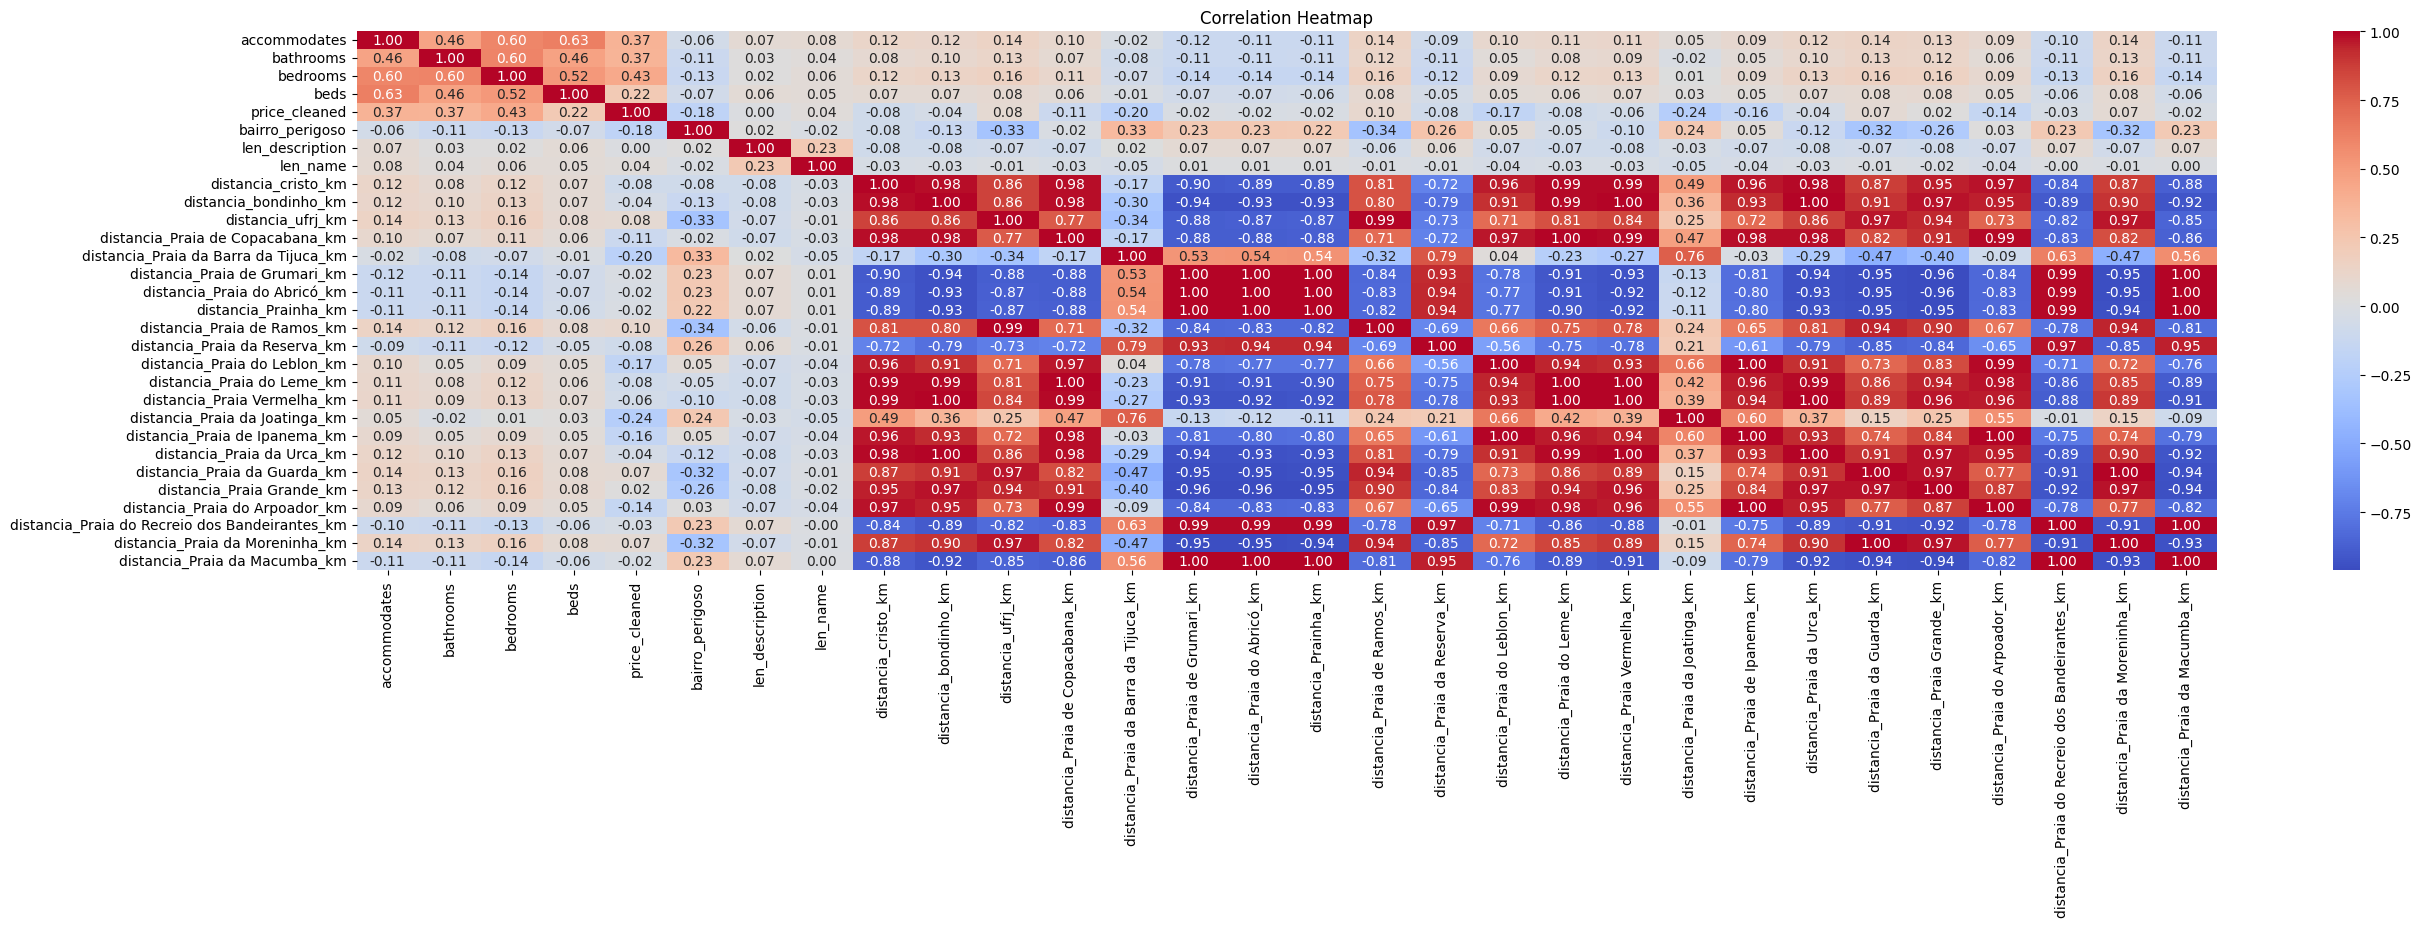

In [19]:
colunas_distancia = [col for col in df_anuncios.columns if col.startswith('distancia_')]

colunas_analise = [#'host_is_superhost', 'latitude', 'longitude', 
                   'room_type','accommodates', 
                   'bathrooms', 'bedrooms', 'beds', #'minimum_nights', 'number_of_reviews', 
                   'price_cleaned', 'bairro_perigoso', #'review_scores_rating', 
                   'len_description', 'len_name' ] + colunas_distancia

corr = df_anuncios[colunas_analise].drop(columns=['room_type']).corr()

plt.figure(figsize=(30, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_anuncios[colunas_analise].copy()

df_arvore_regressora.dropna(inplace=True)

In [21]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [22]:
cat_cols = ['bairro_perigoso','Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'] #'host_is_superhost', 
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds'] + colunas_distancia #, 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name'

In [23]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [24]:
from xgboost import XGBRegressor

precomputador_do_grupo =  ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')
    
pipeline_xgb = Pipeline(steps=[
    ('pre-processamento', precomputador_do_grupo),
    ('modelo', XGBRegressor(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.01,
        # subsample=0.8,
        # colsample_bytree=0.7,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
print(f"R² Score: {r2:.4f}")
print(f"Root mean squared error: {rmse:.4f}\n")

R² Score: 0.4420
Root mean squared error: 279.8530



In [25]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_anuncios[colunas_analise].copy()

df_lasso.dropna(inplace=True)

precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

R² Score: 0.37471174585320466
Root mean squared error: 296.2519615407743


/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.332e+09, tolerance: 4.135e+05
  model = cd_fast.enet_coordinate_descent(


In [28]:
num_cols

['accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'distancia_cristo_km',
 'distancia_bondinho_km',
 'distancia_ufrj_km',
 'distancia_Praia de Copacabana_km',
 'distancia_Praia da Barra da Tijuca_km',
 'distancia_Praia de Grumari_km',
 'distancia_Praia do Abricó_km',
 'distancia_Prainha_km',
 'distancia_Praia de Ramos_km',
 'distancia_Praia da Reserva_km',
 'distancia_Praia do Leblon_km',
 'distancia_Praia do Leme_km',
 'distancia_Praia Vermelha_km',
 'distancia_Praia da Joatinga_km',
 'distancia_Praia de Ipanema_km',
 'distancia_Praia da Urca_km',
 'distancia_Praia da Guarda_km',
 'distancia_Praia Grande_km',
 'distancia_Praia do Arpoador_km',
 'distancia_Praia do Recreio dos Bandeirantes_km',
 'distancia_Praia da Moreninha_km',
 'distancia_Praia da Macumba_km']

In [30]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=30, 
    min_samples_leaf=500,
    random_state=RANDOM_SEED
    )

precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

pipeline_arvore.fit(X_train, y_train)
y_pred_arvore = pipeline_arvore.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.3702202686349496
Root mean squared error: 297.3140541140185


In [31]:
import geopandas as gpd

# 1. Preparar e reprojetar os dados para metros (EPSG:31983)
gdf_praias_m = gdf_praias.to_crs(epsg=31983)

gdf_anuncios = gpd.GeoDataFrame(
    df_anuncios, 
    geometry=gpd.points_from_xy(df_anuncios['longitude'], df_anuncios['latitude']),
    crs="EPSG:4326"
)
gdf_anuncios_m = gdf_anuncios.to_crs(epsg=31983)

# 2. Junção Espacial pela geometria mais próxima
# Ele liga cada anúncio à praia mais perto e cria a coluna 'dist_metros'
anuncios_nearest = gpd.sjoin_nearest(
    gdf_anuncios_m, 
    gdf_praias_m[['name', 'geometry']], # Trazemos apenas o nome e a geometria da praia
    how='left', 
    distance_col='dist_metros'
)

# Correção de segurança: Se um imóvel estiver a exatamente a mesma distância de 
# duas praias (ex: na fronteira exata entre Ipanema e Leblon), o sjoin duplica a linha.
# Esse comando garante que manteremos apenas a primeira correspondência.
anuncios_nearest = anuncios_nearest[~anuncios_nearest.index.duplicated(keep='first')]

# 3. Adicionar os resultados ao seu DataFrame original
# Distância convertida para quilômetros
df_anuncios['distancia_praia_mais_proxima_km'] = anuncios_nearest['dist_metros'] / 1000

# Bônus: Salvar o nome da praia também pode ser uma ótima variável categórica para o modelo!
df_anuncios['nome_praia_mais_proxima'] = anuncios_nearest['name_right']

print("Cálculo concluído! Visualizando os resultados:")
print(df_anuncios[['longitude', 'latitude', 'nome_praia_mais_proxima', 'distancia_praia_mais_proxima_km']].head())


Cálculo concluído! Visualizando os resultados:
   longitude  latitude nome_praia_mais_proxima  \
0  -43.17940 -22.96599     Praia de Copacabana   
1  -43.19122 -22.97649     Praia de Copacabana   
2  -43.19136 -22.98107     Praia de Copacabana   
4  -43.17514 -22.96574     Praia de Copacabana   
5  -43.19008 -22.97910     Praia de Copacabana   

   distancia_praia_mais_proxima_km  
0                         0.230865  
1                         0.322526  
2                         0.199146  
4                         0.041837  
5                         0.119586  


In [32]:
anuncios_nearest

,Unnamed: 0,id,name_left,len_description,len_name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,...,distancia_Praia da Guarda_km,distancia_Praia Grande_km,distancia_Praia do Arpoador_km,distancia_Praia do Recreio dos Bandeirantes_km,distancia_Praia da Moreninha_km,distancia_Praia da Macumba_km,geometry,index_right,name_right,dist_metros
0,0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",533,49,Matthias,"Rio de Janeiro, Brazil",NaN,True,NaN,...,23.378811,10.095553,2.838184,28.171716,23.987262,31.806073,POINT (686646.576 7459087.81),0,Praia de Copacabana,230.865135
1,1,25026,Beautiful Modern Decorated Studio in Copacabana,524,47,Viviane,"Rio de Janeiro, Brazil",NaN,True,NaN,...,24.868238,11.723820,1.324946,26.742271,25.472042,30.369970,POINT (685420.184 7457940.045),0,Praia de Copacabana,322.525999
2,2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,314,47,Patricia&Paulo,"Rio de Janeiro, Brazil",NaN,True,NaN,...,25.351466,12.159808,0.833537,26.634276,25.956194,30.256615,POINT (685399.577 7457433.042),0,Praia de Copacabana,199.146484
4,4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,267,50,Marcio,"Cabo Frio, Brazil",NaN,False,NaN,...,23.223102,9.854416,3.084603,28.603650,23.833813,32.237595,POINT (687083.755 7459110.07),0,Praia de Copacabana,41.836686
5,5,49179,Copacabana Ocean View Studio • Posto 5,399,38,David,"Mesa, AZ",NaN,True,NaN,...,25.102312,11.905221,1.080476,26.802554,25.707354,30.427079,POINT (685533.509 7457649.577),0,Praia de Copacabana,119.586353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40761,40761,1651659432164508192,Quarto privativo com vista para o Corcovado!,255,44,Pedro Varriol,"Rio, Brazil",NaN,True,NaN,...,21.109042,8.387711,5.168437,28.254045,21.707084,31.889783,POINT (686016.824 7461741.541),12,Praia da Urca,2349.496598
40762,40762,1651763680457011689,Aconchego na Glória - Localização perfeita,528,42,Monica,NaN,NaN,False,NaN,...,18.159464,5.947351,8.131278,30.000749,18.754340,33.617924,POINT (686828.754 7464600.049),12,Praia da Urca,3804.938885
40764,40764,1651790928149305935,Av. Atlântica | Vista Mar Incrível | Suíte Premi,420,48,Collins,"Rio de Janeiro, Brazil",NaN,True,NaN,...,23.238248,9.844618,3.107992,28.700819,23.849588,32.334335,POINT (687193.896 7459059.968),0,Praia de Copacabana,0.000000
40765,40765,1652082025241101165,Copacabana: Praia e Conforto | 5 Hóspedes,0,41,Yes Temporada,"Rio, Brazil",NaN,False,NaN,...,22.672601,9.257356,3.696129,29.121665,23.284795,32.757330,POINT (687515.925 7459553.253),8,Praia do Leme,270.532201


In [33]:
df_anuncios.head()

,Unnamed: 0,id,name,len_description,len_name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,...,distancia_Praia de Ipanema_km,distancia_Praia da Urca_km,distancia_Praia da Guarda_km,distancia_Praia Grande_km,distancia_Praia do Arpoador_km,distancia_Praia do Recreio dos Bandeirantes_km,distancia_Praia da Moreninha_km,distancia_Praia da Macumba_km,distancia_praia_mais_proxima_km,nome_praia_mais_proxima
0,0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",533,49,Matthias,"Rio de Janeiro, Brazil",NaN,True,NaN,...,2.904738,2.533314,23.378811,10.095553,2.838184,28.171716,23.987262,31.806073,0.230865,Praia de Copacabana
1,1,25026,Beautiful Modern Decorated Studio in Copacabana,524,47,Viviane,"Rio de Janeiro, Brazil",NaN,True,NaN,...,1.331547,4.205650,24.868238,11.723820,1.324946,26.742271,25.472042,30.369970,0.322526,Praia de Copacabana
2,2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,314,47,Patricia&Paulo,"Rio de Janeiro, Brazil",NaN,True,NaN,...,0.848279,4.603484,25.351466,12.159808,0.833537,26.634276,25.956194,30.256615,0.199146,Praia de Copacabana
4,4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,267,50,Marcio,"Cabo Frio, Brazil",NaN,False,NaN,...,3.182587,2.256466,23.223102,9.854416,3.084603,28.603650,23.833813,32.237595,0.041837,Praia de Copacabana
5,5,49179,Copacabana Ocean View Studio • Posto 5,399,38,David,"Mesa, AZ",NaN,True,NaN,...,1.101085,4.350918,25.102312,11.905221,1.080476,26.802554,25.707354,30.427079,0.119586,Praia de Copacabana


In [34]:
colunas_analise = ['room_type','accommodates', 
    'bathrooms', 'bedrooms', 'beds',
    'price_cleaned', 'bairro_perigoso', 'len_description', 'len_name' ]

In [35]:
cat_cols = ['bairro_perigoso', 'room_type', 'nome_praia_mais_proxima']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'len_description', 'len_name', 'distancia_praia_mais_proxima_km', 'distancia_cristo_km', 'distancia_bondinho_km', 'distancia_ufrj_km']

In [36]:
df_arvore_regressora = df_anuncios[colunas_analise + ['distancia_praia_mais_proxima_km', 'nome_praia_mais_proxima', 'distancia_cristo_km', 'distancia_bondinho_km', 'distancia_ufrj_km']].copy() #

df_arvore_regressora.dropna(inplace=True)

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

In [38]:
# enc = preprocessing.OneHotEncoder()
# enc.fit(df_arvore_regressora[['room_type']])
# one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
# df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [39]:
df_arvore_regressora.head()

,room_type,accommodates,bathrooms,bedrooms,beds,price_cleaned,bairro_perigoso,len_description,len_name,distancia_praia_mais_proxima_km,nome_praia_mais_proxima,distancia_cristo_km,distancia_bondinho_km,distancia_ufrj_km
0,Todo o espaço,5,1.0,2.0,2.0,565.00,0,533,49,0.230865,Praia de Copacabana,3.550735,3.111712,13.726561
1,Todo o espaço,3,1.0,1.0,2.0,542.50,0,524,47,0.322526,Praia de Copacabana,3.365313,4.785237,14.381598
2,Todo o espaço,2,1.5,1.0,1.0,369.00,0,314,47,0.199146,Praia de Copacabana,3.780005,5.135357,14.861281
4,Todo o espaço,9,2.5,4.0,5.0,1314.67,0,267,50,0.041837,Praia de Copacabana,3.936992,2.760116,13.885405
5,Todo o espaço,2,1.0,1.0,1.0,339.50,0,399,38,0.119586,Praia de Copacabana,3.668659,4.889717,14.692538


In [40]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [41]:
from xgboost import XGBRegressor

precomputador_do_grupo =  ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')
    
pipeline_xgb = Pipeline(steps=[
    ('pre-processamento', precomputador_do_grupo),
    ('modelo', XGBRegressor(
        n_estimators=300,
        max_depth=9,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
print(f"R² Score: {r2:.4f}")
print(f"Root mean squared error: {rmse:.4f}\n")

R² Score: 0.4470
Root mean squared error: 278.6001



In [42]:
pipeline_xgb.feature_names_in_

array(['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'bairro_perigoso', 'len_description', 'len_name',
       'distancia_praia_mais_proxima_km', 'nome_praia_mais_proxima',
       'distancia_cristo_km', 'distancia_bondinho_km',
       'distancia_ufrj_km'], dtype=object)

In [43]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=10, 
    min_samples_leaf=200,
    random_state=RANDOM_SEED
    )

precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

pipeline_arvore.fit(X_train, y_train)
y_pred_arvore = pipeline_arvore.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.3868425101036105
Root mean squared error: 293.3642023126861


In [44]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_arvore_regressora.copy()

df_lasso.dropna(inplace=True)

In [ ]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.01, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

In [ ]:
colunas_desejadas = ['id', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_cleaned', 'bairro_perigoso', 'len_description', 'len_name', 'nome_praia_mais_proxima', 'distancia_praia_mais_proxima_km', 'distancia_cristo_km', 'distancia_bondinho_km', 'distancia_ufrj_km']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna() 
    for nome_grupo, dados in df_anuncios.groupby('room_type')
}

In [ ]:
cat_cols = ['bairro_perigoso', 'nome_praia_mais_proxima']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'distancia_praia_mais_proxima_km', 'distancia_cristo_km', 'distancia_bondinho_km', 'distancia_ufrj_km']

In [ ]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [ ]:
modelos_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

predicoes_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

metricas_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

In [ ]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"
CASO = "tipos_de_quarto"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---
R² Score: -0.5932
Root mean squared error: 151.9540


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.1249
Root mean squared error: 267.6891


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.4121
Root mean squared error: 292.3436

